In [ ]:
import numpy as np
from rolland.database.rail.db_rail import UIC60


from utils import interpolate_contour_2d, create_mesh, calculate_centre_and_area_triangles, calculate_projected_area, \
    assign_v_to_points, vector_deflection_total

In [ ]:
u_y_pos_1_f16 = np.load('provided_data/u_y_exc_at_pos1.npy').astype(np.float16)
u_y_pos_2_f16 = np.load('provided_data/u_y_exc_at_pos2.npy').astype(np.float16)
u_z_pos_1_f16 = np.load('provided_data/u_z_exc_at_pos1.npy').astype(np.float16)
u_z_pos_2_f16 = np.load('provided_data/u_z_exc_at_pos2.npy').astype(np.float16)
phi_x_pos1_f16 = np.load('provided_data/phi_x_exc_at_pos1.npy').astype(np.float16)
phi_x_pos2_f16 = np.load('provided_data/phi_x_exc_at_pos2.npy').astype(np.float16)

In [ ]:
L = [1, 5, 10, 20, 50]
import time
results = {}
for l in L:
    start = time.time()


    rail_geometry = UIC60.rl_geo
    length = l
    rail_geometry = interpolate_contour_2d(rail_geometry, 25)
    triangle_coords, triangle_index = create_mesh(rail_geometry,
                                                  mesh_size=0.05,
                                                  L=length  #146.0
                                                  )

    A, centre, norm = calculate_centre_and_area_triangles(triangle_coords, triangle_index)
    print(f'mean area = {A.mean()}')
    projected_area = calculate_projected_area(A, norm, 1)
    dx = 0.05
    dt = 0.5e-5

    excitation_point = 0.65 * 50 + 0.65 / 2
    cut_start_m = excitation_point - length / 2

    n_x_cut = int(round(length / dx)) + 1
    start_index = int(round(cut_start_m / dx))
    end_index = start_index + n_x_cut

    centre_sim = centre.copy()
    centre_sim[:, 2] = centre_sim[:, 2] + cut_start_m

    from utils import vector_deflection_total
    u_y = u_y_pos_1_f16 + u_y_pos_2_f16
    u_z = u_z_pos_1_f16 + u_z_pos_2_f16
    phi_x = phi_x_pos1_f16 + phi_x_pos2_f16

    u_y = u_y[:, start_index:end_index]
    u_z = u_z[:, start_index:end_index]
    phi_x = phi_x[:, start_index:end_index]

    import scipy as sp
    f_sim_axis = sp.fft.fftfreq(u_z.shape[0], 0.5e-5)
    u_y = sp.fft.fft(u_y, norm='forward', axis=0) * 2
    u_z = sp.fft.fft(u_z, norm='forward', axis=0) * 2
    phi_x = sp.fft.fft(phi_x, norm='forward', axis=0) * 2
    f_min = 0
    f_max = 3000
    frequncy_mask = (f_sim_axis >= f_min) & (f_sim_axis <= f_max)

    u_y = u_y[frequncy_mask, :]
    u_z = u_z[frequncy_mask, :]
    phi_x = phi_x[frequncy_mask, :]

    omega = 2 * np.pi * f_sim_axis[frequncy_mask]
    v_y = (1j * omega[:, None]) * u_y
    v_z = (1j * omega[:, None]) * u_z
    phi_x = (1j * omega[:, None]) * phi_x

    triangle_v_y, triangle_v_z = vector_deflection_total(
        v_y,
        v_z,
        phi_x,
        centre,
    )
    y_projected_area = calculate_projected_area(A, norm, 0)
    z_projected_area = calculate_projected_area(A, norm, 1)
    from matplotlib import pyplot as plt
    import numpy as np
    from utils import run_simulation_semi_circle_total
    from frequency_domain import monopole_multi_fa__calcf__outf
    semi_circle_centre = np.array((-0.71, -0.08, excitation_point))

    P_total, P_z, P_y = run_simulation_semi_circle_total(
        circle_centre=semi_circle_centre,
        circle_radius=2.5,
        number_of_points=5,
        simulation_function=monopole_multi_fa__calcf__outf,
        V_z=triangle_v_z.T,
        A_z=z_projected_area[:, None],
        V_y=triangle_v_y.T,
        A_y=y_projected_area[:, None],
        return_components=True,
        freqs=f_sim_axis[frequncy_mask],
        X=centre_sim,
    )

    p0 = 2e-5

    P_total_db = 20 * np.log10((np.abs(P_total) + p0) / p0)
    P_z_db = 20 * np.log10((np.abs(P_z) + p0) / p0)
    P_y_db = 20 * np.log10((np.abs(P_y) + p0) / p0)

    f_plot = f_sim_axis[frequncy_mask]
    plt_mask = (f_plot >= 100) & (f_plot <= f_max)

    plt_f_axis = f_plot[plt_mask]
    plt_P_total_db = P_total_db[plt_mask]
    plt_P_z_db = P_z_db[plt_mask]
    plt_P_y_db = P_y_db[plt_mask]

    plt.plot(plt_f_axis, plt_P_total_db, label="P_total")
    plt.plot(plt_f_axis, plt_P_z_db, label="P_z")
    plt.xlabel('Frequenz [Hz]')
    plt.ylabel('Schalldruckpegel [dB]')
    plt.legend()
    plt.xscale('log')
    plt.grid(True, which='major')
    plt.grid(True, which='minor', linestyle=':', alpha=0.5)
    plt.title('Schalldruckpegel ')
    plt.show()

    end = time.time()
    time_elapsed = end - start
    results[l] = {
        "freq": plt_f_axis.copy(),
        "P_total": P_total.copy(),
        "P_z": plt_P_z_db.copy(),
        "P_y": plt_P_y_db.copy(),
        'time': time_elapsed
    }

## Comparisons:

1. Comparison for simulated rail length of 1m, 5m and 10m
2. Comparison for different mesh sizes 0.025m, 0.05m, 0.1m, 0.25m
3. Comparison for different interpolation points 10, 25, 50
4. Comparison for different data types float16, float32, float64

referance values for the comparisons are:
ref_length = 5m
ref_mesh_size = 0.05m
ref_interpolation_points = 25
ref_data_type = float16

In [ ]:
for result in results.values():
    print(result['time'])

In [ ]:
p0 = 2e-5
for l in L:
    P_total = results[l]['P_total']
    P_total_db = 20 * np.log10((np.abs(P_total) + p0) / p0)
    # P_z_db = 20 * np.log10((np.abs(P_z) + p0) / p0)
    # P_y_db = 20 * np.log10((np.abs(P_y) + p0) / p0)

    f_plot = f_sim_axis[frequncy_mask]
    plt_mask = (f_plot >= 100) & (f_plot <= f_max)

    plt_f_axis = f_plot[plt_mask]
    plt_P_total_db = P_total_db[plt_mask]
    plt_P_z_db = P_z_db[plt_mask]
    plt_P_y_db = P_y_db[plt_mask]

    plt.plot(plt_f_axis, plt_P_total_db, label="P_total")

plt.xlabel('Frequenz [Hz]')
plt.ylabel('Schalldruckpegel [dB]')
plt.legend()
plt.xscale('log')
plt.grid(True, which='major')
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.title('Schalldruckpegel ')
plt.show()

In [ ]:
p0 = 2e-5
#plt.figure(figsize=(9, 5))

for l in L:
    P_total = results[l]['P_total']
    P_total_db = 20 * np.log10((np.abs(P_total) + p0) / p0)

    f_plot = f_sim_axis[frequncy_mask]
    plt_mask = (f_plot >= 100) & (f_plot <= f_max)

    plt_f_axis = f_plot[plt_mask]
    plt_P_total_db = P_total_db[plt_mask]

    plt.plot(
        plt_f_axis,
        plt_P_total_db,
        linewidth=2,
        label=f"L = {l} m"
    )

plt.xlabel('Frequenz [Hz]')
plt.ylabel('Schalldruckpegel [dB]')
plt.title('Schalldruckpegel für verschiedene Schienenlängen')

plt.xscale('log')

plt.grid(True, which='major', linewidth=0.8)
plt.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.legend(loc='upper left', title='Schienenlänge')
plt.savefig('performance_comparison_length', bbox_inches='tight')

#plt.tight_layout()
plt.show()

In [ ]:
p0 = 2e-5

ref = results[5]['P_total']
ref_db = 20 * np.log10((np.abs(ref) + p0) / p0)
L_p_ref = 10 * np.log10(np.sum(10 ** (ref_db / 10)))
L_p_RMS_ref = 10 * np.log10((np.sqrt(np.sum(np.abs(ref) ** 2 )))/p0**2)
print(f'L_p_ref = {L_p_ref}')

diff_list = []

for l in L:
    if l == 5:
        continue

    P = results[l]['P_total']
    P_db = 20 * np.log10((np.abs(P) + p0) / p0)

    diff = P_db - ref_db

    # apply same frequency window as your plots
    diff = diff[plt_mask]

    mean_diff = np.mean(np.abs(diff))
    max_diff = np.max(np.abs(diff))

    diff_list.append((l, mean_diff, max_diff))


for l, mean_d, max_d in diff_list:
    print(f"L={l} m | mean Δ = {mean_d:.3f} dB | max Δ = {max_d:.3f} dB")

for l in L:
    if l == 5:
        continue

    P = results[l]['P_total']
    L_p = 10 * np.log10((np.sqrt(np.sum(np.abs(P) ** 2 )))/p0**2)
    print(L_p_ref - L_p)





In [ ]:
level_list = []

for l in L:
    P = results[l]['P_total']
    P_lin = np.abs(P)**2   # energy

    P_lin = P_lin[plt_mask]

    L_eq = 10 * np.log10(np.mean(P_lin) / (p0**2))

    level_list.append((l, L_eq))

for l, Leq in level_list:
    print(f"L={l} m | L_eq = {Leq:.2f} dB")

    ref_Leq = dict(level_list)[5]

for l, Leq in level_list:
    if l == 5:
        continue
    print(f"L={l} m | ΔL_eq = {Leq - ref_Leq:.3f} dB")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

p0 = 2e-5
f_max = 3000

freq_ref = results[5]['freq']
ref_db = 20 * np.log10((np.abs(results[5]['P_total']) + p0) / p0)
if ref_db.shape[0] != freq_ref.shape[0]:
    ref_db = ref_db[-freq_ref.shape[0]:]

plt.figure()

for l in L:
    if l == 5:
        continue

    freq = results[l]['freq']
    P_db = 20 * np.log10((np.abs(results[l]['P_total']) + p0) / p0)
    if P_db.shape[0] != freq.shape[0]:
        P_db = P_db[-freq.shape[0]:]

    if freq.shape != freq_ref.shape or not np.allclose(freq, freq_ref):
        P_db = np.interp(freq_ref, freq, P_db)
        f_plot = freq_ref
    else:
        f_plot = freq

    diff = P_db - ref_db
    mask = (f_plot >= 100) & (f_plot <= f_max)

    plt.plot(f_plot[mask], diff[mask], label=f"L={l} m")

plt.xlabel("Frequenz [Hz]")
plt.ylabel("Differenz in Schalldruckpegel [dB]")
plt.title("Schalldruckpegeldifferenz relativ zur Referenzlänge (L = 5 m)")
plt.xscale('log')
plt.legend(loc='upper left', title='Schienenlänge')
plt.grid(True, which='major')
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.savefig('performance_comparison_length_differences', bbox_inches='tight')
plt.show()

In [ ]:
mesh = [0.5, 0.25, 0.05, 0.025, 0.01]
l=5
import time
results = {}
for n in mesh:
    start = time.time()


    rail_geometry = UIC60.rl_geo
    length = l
    rail_geometry = interpolate_contour_2d(rail_geometry, 25)
    triangle_coords, triangle_index = create_mesh(rail_geometry,
                                                  mesh_size=n,
                                                  L=length  #146.0
                                                  )

    A, centre, norm = calculate_centre_and_area_triangles(triangle_coords, triangle_index)
    print(f'mean area = {A.mean()}')
    projected_area = calculate_projected_area(A, norm, 1)
    dx = 0.05
    dt = 0.5e-5

    excitation_point = 0.65 * 50 + 0.65 / 2
    cut_start_m = excitation_point - length / 2

    n_x_cut = int(round(length / dx)) + 1
    start_index = int(round(cut_start_m / dx))
    end_index = start_index + n_x_cut

    centre_sim = centre.copy()
    centre_sim[:, 2] = centre_sim[:, 2] + cut_start_m

    from utils import vector_deflection_total
    u_y = u_y_pos_1_f16 + u_y_pos_2_f16
    u_z = u_z_pos_1_f16 + u_z_pos_2_f16
    phi_x = phi_x_pos1_f16 + phi_x_pos2_f16

    u_y = u_y[:, start_index:end_index]
    u_z = u_z[:, start_index:end_index]
    phi_x = phi_x[:, start_index:end_index]

    import scipy as sp
    f_sim_axis = sp.fft.fftfreq(u_z.shape[0], 0.5e-5)
    u_y = sp.fft.fft(u_y, norm='forward', axis=0) * 2
    u_z = sp.fft.fft(u_z, norm='forward', axis=0) * 2
    phi_x = sp.fft.fft(phi_x, norm='forward', axis=0) * 2
    f_min = 0
    f_max = 3000
    frequncy_mask = (f_sim_axis >= f_min) & (f_sim_axis <= f_max)

    u_y = u_y[frequncy_mask, :]
    u_z = u_z[frequncy_mask, :]
    phi_x = phi_x[frequncy_mask, :]

    omega = 2 * np.pi * f_sim_axis[frequncy_mask]
    v_y = (1j * omega[:, None]) * u_y
    v_z = (1j * omega[:, None]) * u_z
    phi_x = (1j * omega[:, None]) * phi_x

    triangle_v_y, triangle_v_z = vector_deflection_total(
        v_y,
        v_z,
        phi_x,
        centre,
    )
    y_projected_area = calculate_projected_area(A, norm, 0)
    z_projected_area = calculate_projected_area(A, norm, 1)
    from matplotlib import pyplot as plt
    import numpy as np
    from utils import run_simulation_semi_circle_total
    from frequency_domain import monopole_multi_fa__calcf__outf
    semi_circle_centre = np.array((-0.71, -0.08, excitation_point))

    P_total, P_z, P_y = run_simulation_semi_circle_total(
        circle_centre=semi_circle_centre,
        circle_radius=2.5,
        number_of_points=5,
        simulation_function=monopole_multi_fa__calcf__outf,
        V_z=triangle_v_z.T,
        A_z=z_projected_area[:, None],
        V_y=triangle_v_y.T,
        A_y=y_projected_area[:, None],
        return_components=True,
        freqs=f_sim_axis[frequncy_mask],
        X=centre_sim,
    )

    p0 = 2e-5

    P_total_db = 20 * np.log10((np.abs(P_total) + p0) / p0)
    P_z_db = 20 * np.log10((np.abs(P_z) + p0) / p0)
    P_y_db = 20 * np.log10((np.abs(P_y) + p0) / p0)

    f_plot = f_sim_axis[frequncy_mask]
    plt_mask = (f_plot >= 100) & (f_plot <= f_max)

    plt_f_axis = f_plot[plt_mask]
    plt_P_total_db = P_total_db[plt_mask]
    plt_P_z_db = P_z_db[plt_mask]
    plt_P_y_db = P_y_db[plt_mask]

    plt.plot(plt_f_axis, plt_P_total_db, label="P_total")
    plt.plot(plt_f_axis, plt_P_z_db, label="P_z")
    plt.xlabel('Frequenz [Hz]')
    plt.ylabel('Schalldruckpegel [dB]')
    plt.legend()
    plt.xscale('log')
    plt.grid(True, which='major')
    plt.grid(True, which='minor', linestyle=':', alpha=0.5)
    plt.title('Schalldruckpegel ')
    plt.show()

    end = time.time()
    time_elapsed = end - start
    results[n] = {
        "freq": plt_f_axis.copy(),
        "P_total": P_total.copy(),
        "P_z": plt_P_z_db.copy(),
        "P_y": plt_P_y_db.copy(),
        'time': time_elapsed
    }

In [ ]:
for result in results.values():
    print(result['time'])


In [ ]:
p0 = 2e-5
#plt.figure(figsize=(9, 5))

for n in mesh:
    P_total = results[n]['P_total']
    P_total_db = 20 * np.log10((np.abs(P_total) + p0) / p0)

    f_plot = f_sim_axis[frequncy_mask]
    plt_mask = (f_plot >= 100) & (f_plot <= f_max)

    plt_f_axis = f_plot[plt_mask]
    plt_P_total_db = P_total_db[plt_mask]

    plt.plot(
        plt_f_axis,
        plt_P_total_db,
        linewidth=2,
        label=f"h = {n} m",
        alpha=0.7,
    )

plt.xlabel('Frequenz [Hz]')
plt.ylabel('Schalldruckpegel [dB]')
plt.title('Schalldruckpegel für verschiedene Diskretisierungsschrittweiten')

plt.xscale('log')

plt.grid(True, which='major', linewidth=0.8)
plt.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.legend(loc='upper left', title='Diskretisierungsschrittweite')
plt.savefig('performance_comparison_meshsize', bbox_inches='tight')

#plt.tight_layout()
plt.show()

In [ ]:
p0 = 2e-5

ref = results[0.05]['P_total']
ref_db = 20 * np.log10((np.abs(ref) + p0) / p0)
L_p_ref = 10 * np.log10(np.sum(10 ** (ref_db / 10)))
L_p_RMS_ref = 10 * np.log10((np.sqrt(np.sum(np.abs(ref) ** 2 )))/p0**2)
print(f'L_p_ref = {L_p_ref}')

diff_list = []

for n in mesh:
    if n == 0.05:
        continue

    P = results[n]['P_total']
    P_db = 20 * np.log10((np.abs(P) + p0) / p0)

    diff = P_db - ref_db

    # apply same frequency window as your plots
    diff = diff[plt_mask]

    mean_diff = np.mean(np.abs(diff))
    max_diff = np.max(np.abs(diff))

    diff_list.append((n, mean_diff, max_diff))


for n, mean_d, max_d in diff_list:
    print(f"mesh={n} m | mean Δ = {mean_d:.3f} dB | max Δ = {max_d:.3f} dB")

for n in mesh:
    if n == 0.05:
        continue

    P = results[n]['P_total']
    L_p = 10 * np.log10((np.sqrt(np.sum(np.abs(P) ** 2 )))/p0**2)
    print(L_p_ref - L_p)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

p0 = 2e-5

ref_db = 20 * np.log10((np.abs(results[0.05]['P_total']) + p0) / p0)

for n in mesh:
    if n == 0.05:
        continue

    freq = results[n]['freq']
    P_db = 20 * np.log10((np.abs(results[n]['P_total']) + p0) / p0)

    diff = P_db[plt_mask] - ref_db[plt_mask]

    plt.plot(freq, diff, label=f"h = {n} m",
             alpha=0.7,
             linewidth=2)

plt.xlabel('Frequenz [Hz]')
plt.ylabel('Schalldruckpegel [dB]')
plt.title('Schalldruckpegeldifferenz relativ zur\nReferenzdiskretisierungsschrittweite (h = 0.05 m)')
plt.xscale('log')
plt.legend(loc='upper left', title='Diskretisierungsschrittweite')
plt.grid(True, which='major', linewidth=0.8)
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.savefig('performance_comparison_meshsize_difference', bbox_inches='tight')
plt.show()

In [ ]:
interpolate = [5, 10, 25, 50, 100]
l=5
n=0.05
import time
results = {}
for i in interpolate:
    start = time.time()


    rail_geometry = UIC60.rl_geo
    length = l
    rail_geometry = interpolate_contour_2d(rail_geometry, i)
    triangle_coords, triangle_index = create_mesh(rail_geometry,
                                                  mesh_size=n,
                                                  L=length  #146.0
                                                  )

    A, centre, norm = calculate_centre_and_area_triangles(triangle_coords, triangle_index)
    print(f'mean area = {A.mean()}')
    projected_area = calculate_projected_area(A, norm, 1)
    dx = 0.05
    dt = 0.5e-5

    excitation_point = 0.65 * 50 + 0.65 / 2
    cut_start_m = excitation_point - length / 2

    n_x_cut = int(round(length / dx)) + 1
    start_index = int(round(cut_start_m / dx))
    end_index = start_index + n_x_cut

    centre_sim = centre.copy()
    centre_sim[:, 2] = centre_sim[:, 2] + cut_start_m

    from utils import vector_deflection_total
    u_y = u_y_pos_1_f16 + u_y_pos_2_f16
    u_z = u_z_pos_1_f16 + u_z_pos_2_f16
    phi_x = phi_x_pos1_f16 + phi_x_pos2_f16

    u_y = u_y[:, start_index:end_index]
    u_z = u_z[:, start_index:end_index]
    phi_x = phi_x[:, start_index:end_index]

    import scipy as sp
    f_sim_axis = sp.fft.fftfreq(u_z.shape[0], 0.5e-5)
    u_y = sp.fft.fft(u_y, norm='forward', axis=0) * 2
    u_z = sp.fft.fft(u_z, norm='forward', axis=0) * 2
    phi_x = sp.fft.fft(phi_x, norm='forward', axis=0) * 2
    f_min = 0
    f_max = 3000
    frequncy_mask = (f_sim_axis >= f_min) & (f_sim_axis <= f_max)

    u_y = u_y[frequncy_mask, :]
    u_z = u_z[frequncy_mask, :]
    phi_x = phi_x[frequncy_mask, :]

    omega = 2 * np.pi * f_sim_axis[frequncy_mask]
    v_y = (1j * omega[:, None]) * u_y
    v_z = (1j * omega[:, None]) * u_z
    phi_x = (1j * omega[:, None]) * phi_x

    triangle_v_y, triangle_v_z = vector_deflection_total(
        v_y,
        v_z,
        phi_x,
        centre,
    )
    y_projected_area = calculate_projected_area(A, norm, 0)
    z_projected_area = calculate_projected_area(A, norm, 1)
    from matplotlib import pyplot as plt
    import numpy as np
    from utils import run_simulation_semi_circle_total
    from frequency_domain import monopole_multi_fa__calcf__outf
    semi_circle_centre = np.array((-0.71, -0.08, excitation_point))

    P_total, P_z, P_y = run_simulation_semi_circle_total(
        circle_centre=semi_circle_centre,
        circle_radius=2.5,
        number_of_points=5,
        simulation_function=monopole_multi_fa__calcf__outf,
        V_z=triangle_v_z.T,
        A_z=z_projected_area[:, None],
        V_y=triangle_v_y.T,
        A_y=y_projected_area[:, None],
        return_components=True,
        freqs=f_sim_axis[frequncy_mask],
        X=centre_sim,
    )

    p0 = 2e-5

    P_total_db = 20 * np.log10((np.abs(P_total) + p0) / p0)
    P_z_db = 20 * np.log10((np.abs(P_z) + p0) / p0)
    P_y_db = 20 * np.log10((np.abs(P_y) + p0) / p0)

    f_plot = f_sim_axis[frequncy_mask]
    plt_mask = (f_plot >= 100) & (f_plot <= f_max)

    plt_f_axis = f_plot[plt_mask]
    plt_P_total_db = P_total_db[plt_mask]
    plt_P_z_db = P_z_db[plt_mask]
    plt_P_y_db = P_y_db[plt_mask]

    plt.plot(plt_f_axis, plt_P_total_db, label="P_total")
    plt.plot(plt_f_axis, plt_P_z_db, label="P_z")
    plt.xlabel('Frequenz [Hz]')
    plt.ylabel('Schalldruckpegel [dB]')
    plt.legend()
    plt.xscale('log')
    plt.grid(True, which='major')
    plt.grid(True, which='minor', linestyle=':', alpha=0.5)
    plt.title('Schalldruckpegel ')
    plt.show()

    end = time.time()
    time_elapsed = end - start
    results[i] = {
        "freq": plt_f_axis.copy(),
        "P_total": P_total.copy(),
        "P_z": plt_P_z_db.copy(),
        "P_y": plt_P_y_db.copy(),
        'time': time_elapsed
    }

In [ ]:
for result in results.values():
    print(result['time'])

In [ ]:
p0 = 2e-5
#plt.figure(figsize=(9, 5))

for i in interpolate:
    P_total = results[i]['P_total']
    P_total_db = 20 * np.log10((np.abs(P_total) + p0) / p0)

    f_plot = f_sim_axis[frequncy_mask]
    plt_mask = (f_plot >= 100) & (f_plot <= f_max)

    plt_f_axis = f_plot[plt_mask]
    plt_P_total_db = P_total_db[plt_mask]

    plt.plot(
        plt_f_axis,
        plt_P_total_db,
        linewidth=2,
        label=f"n = {i}",
        alpha=0.7,
    )

plt.xlabel('Frequenz [Hz]')
plt.ylabel('Schalldruckpegel [dB]')
plt.title('Schalldruckpegel für verschiedene Querschnittsdiskretisierung')

plt.xscale('log')

plt.grid(True, which='major', linewidth=0.8)
plt.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.legend(loc='upper left', title='Anzahl Stützstellen')
plt.savefig('performance_comparison_interpolate', bbox_inches='tight')

#plt.tight_layout()
plt.show()

In [ ]:
p0 = 2e-5

ref = results[25]['P_total']
ref_db = 20 * np.log10((np.abs(ref) + p0) / p0)
L_p_ref = 10 * np.log10(np.sum(10 ** (ref_db / 10)))
L_p_RMS_ref = 10 * np.log10((np.sqrt(np.sum(np.abs(ref) ** 2 )))/p0**2)
print(f'L_p_ref = {L_p_ref}')

diff_list = []

for i in interpolate:
    if i == 25:
        continue

    P = results[i]['P_total']
    P_db = 20 * np.log10((np.abs(P) + p0) / p0)

    diff = P_db - ref_db

    # apply same frequency window as your plots
    diff = diff[plt_mask]

    mean_diff = np.mean(np.abs(diff))
    max_diff = np.max(np.abs(diff))

    diff_list.append((i, mean_diff, max_diff))


for i, mean_d, max_d in diff_list:
    print(f"number={i} m | mean Δ = {mean_d:.3f} dB | max Δ = {max_d:.3f} dB")

for i in interpolate:
    if i == 25:
        continue

    P = results[i]['P_total']
    L_p = 10 * np.log10((np.sqrt(np.sum(np.abs(P) ** 2 )))/p0**2)
    print(L_p_ref - L_p)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

p0 = 2e-5

ref_db = 20 * np.log10((np.abs(results[25]['P_total']) + p0) / p0)

for i in interpolate:
    if i == 25:
        continue

    freq = results[i]['freq']
    P_db = 20 * np.log10((np.abs(results[i]['P_total']) + p0) / p0)

    diff = P_db[plt_mask] - ref_db[plt_mask]

    plt.plot(freq, diff, label=f"n = {i}",
             alpha=0.7,
             linewidth=2)

plt.xlabel('Frequenz [Hz]')
plt.ylabel('Schalldruckpegel [dB]')
plt.title('Schalldruckpegeldifferenz relativ zur\nQuerschnittsdiskretisierung (n = 25)')
plt.xscale('log')
plt.legend(loc='upper left', title='Anzahl Stützstellen')
plt.grid(True, which='major', linewidth=0.8)
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.savefig('performance_comparison_interpolate_difference', bbox_inches='tight')
plt.show()

In [ ]:
dtypes = [np.float16, np.float32, np.float64]
l = 5
results = {}
for dtype in dtypes:
    u_y_pos_1 = np.load('provided_data/u_y_exc_at_pos1.npy').astype(dtype)
    u_y_pos_2 = np.load('provided_data/u_y_exc_at_pos2.npy').astype(dtype)
    u_z_pos_1 = np.load('provided_data/u_z_exc_at_pos1.npy').astype(dtype)
    u_z_pos_2 = np.load('provided_data/u_z_exc_at_pos2.npy').astype(dtype)
    phi_x_pos1 = np.load('provided_data/phi_x_exc_at_pos1.npy').astype(dtype)
    phi_x_pos2 = np.load('provided_data/phi_x_exc_at_pos2.npy').astype(dtype)

    u_y = u_y_pos_1 + u_y_pos_2
    u_z = u_z_pos_1 + u_z_pos_2
    phi_x = phi_x_pos1 + phi_x_pos2
    start = time.time()


    rail_geometry = UIC60.rl_geo
    length = l
    rail_geometry = interpolate_contour_2d(rail_geometry, 25)
    triangle_coords, triangle_index = create_mesh(rail_geometry,
                                                  mesh_size=0.05,
                                                  L=length  #146.0
                                                  )
    A, centre, norm = calculate_centre_and_area_triangles(triangle_coords, triangle_index)
    print(f'mean area = {A.mean()}')
    projected_area = calculate_projected_area(A, norm, 1)
    dx = 0.05
    dt = 0.5e-5

    excitation_point = 0.65 * 50 + 0.65 / 2
    cut_start_m = excitation_point - length / 2

    n_x_cut = int(round(length / dx)) + 1
    start_index = int(round(cut_start_m / dx))
    end_index = start_index + n_x_cut

    centre_sim = centre.copy()
    centre_sim[:, 2] = centre_sim[:, 2] + cut_start_m

    u_y = u_y[:, start_index:end_index]
    u_z = u_z[:, start_index:end_index]
    phi_x = phi_x[:, start_index:end_index]

    import scipy as sp
    f_sim_axis = sp.fft.fftfreq(u_z.shape[0], 0.5e-5)
    u_y = sp.fft.fft(u_y, norm='forward', axis=0) * 2
    u_z = sp.fft.fft(u_z, norm='forward', axis=0) * 2
    phi_x = sp.fft.fft(phi_x, norm='forward', axis=0) * 2
    f_min = 0
    f_max = 3000
    frequncy_mask = (f_sim_axis >= f_min) & (f_sim_axis <= f_max)

    u_y = u_y[frequncy_mask, :]
    u_z = u_z[frequncy_mask, :]
    phi_x = phi_x[frequncy_mask, :]

    omega = 2 * np.pi * f_sim_axis[frequncy_mask]
    v_y = (1j * omega[:, None]) * u_y
    v_z = (1j * omega[:, None]) * u_z
    phi_x = (1j * omega[:, None]) * phi_x

    triangle_v_y, triangle_v_z = vector_deflection_total(
        v_y,
        v_z,
        phi_x,
        centre,
    )
    y_projected_area = calculate_projected_area(A, norm, 0)
    z_projected_area = calculate_projected_area(A, norm, 1)
    from matplotlib import pyplot as plt
    import numpy as np
    from utils import run_simulation_semi_circle_total
    from frequency_domain import monopole_multi_fa__calcf__outf
    semi_circle_centre = np.array((-0.71, -0.08, excitation_point))

    P_total, P_z, P_y = run_simulation_semi_circle_total(
        circle_centre=semi_circle_centre,
        circle_radius=2.5,
        number_of_points=5,
        simulation_function=monopole_multi_fa__calcf__outf,
        V_z=triangle_v_z.T,
        A_z=z_projected_area[:, None],
        V_y=triangle_v_y.T,
        A_y=y_projected_area[:, None],
        return_components=True,
        freqs=f_sim_axis[frequncy_mask],
        X=centre_sim,
    )

    p0 = 2e-5

    P_total_db = 20 * np.log10((np.abs(P_total) + p0) / p0)
    P_z_db = 20 * np.log10((np.abs(P_z) + p0) / p0)
    P_y_db = 20 * np.log10((np.abs(P_y) + p0) / p0)

    f_plot = f_sim_axis[frequncy_mask]
    plt_mask = (f_plot >= 100) & (f_plot <= f_max)

    plt_f_axis = f_plot[plt_mask]
    plt_P_total_db = P_total_db[plt_mask]
    plt_P_z_db = P_z_db[plt_mask]
    plt_P_y_db = P_y_db[plt_mask]

    plt.plot(plt_f_axis, plt_P_total_db, label="P_total")
    plt.plot(plt_f_axis, plt_P_z_db, label="P_z")
    plt.xlabel('Frequenz [Hz]')
    plt.ylabel('Schalldruckpegel [dB]')
    plt.legend()
    plt.xscale('log')
    plt.grid(True, which='major')
    plt.grid(True, which='minor', linestyle=':', alpha=0.5)
    plt.title('Schalldruckpegel ')
    plt.show()

    end = time.time()
    time_elapsed = end - start
    results[dtype] = {
        "freq": plt_f_axis.copy(),
        "P_total": P_total.copy(),
        "P_z": plt_P_z_db.copy(),
        "P_y": plt_P_y_db.copy(),
        'time': time_elapsed
    }

In [ ]:
for result in results.values():
    print(result['time'])

In [ ]:
p0 = 2e-5
#plt.figure(figsize=(9, 5))

for dtype in dtypes:
    P_total = results[dtype]['P_total']
    P_total_db = 20 * np.log10((np.abs(P_total) + p0) / p0)

    f_plot = f_sim_axis[frequncy_mask]
    plt_mask = (f_plot >= 100) & (f_plot <= f_max)

    plt_f_axis = f_plot[plt_mask]
    plt_P_total_db = P_total_db[plt_mask]

    plt.plot(
        plt_f_axis,
        plt_P_total_db,
        linewidth=2,
        label=f"Datentyp = {dtype.__name__}",
        alpha=0.7,
    )

plt.xlabel('Frequenz [Hz]')
plt.ylabel('Schalldruckpegel [dB]')
plt.title('Schalldruckpegel für verschiedene Datentypen')

plt.xscale('log')

plt.grid(True, which='major', linewidth=0.8)
plt.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.legend(loc='upper left', title='Datentyp')
plt.savefig('performance_comparison_datatype', bbox_inches='tight')

#plt.tight_layout()
plt.show()

In [ ]:
p0 = 2e-5

ref = results[np.float16]['P_total']
ref_db = 20 * np.log10((np.abs(ref) + p0) / p0)
L_p_ref = 10 * np.log10(np.sum(10 ** (ref_db / 10)))
L_p_RMS_ref = 10 * np.log10((np.sqrt(np.sum(np.abs(ref) ** 2 )))/p0**2)
print(f'L_p_ref = {L_p_ref}')

diff_list = []

for dtype in dtypes:
    if dtype is np.float16:
        continue

    P = results[dtype]['P_total']
    P_db = 20 * np.log10((np.abs(P) + p0) / p0)

    diff = P_db - ref_db

    # apply same frequency window as your plots
    diff = diff[plt_mask]

    mean_diff = np.mean(np.abs(diff))
    max_diff = np.max(np.abs(diff))

    diff_list.append((dtype, mean_diff, max_diff))


for dtype, mean_d, max_d in diff_list:
    print(f"dtype={dtype.__name__} | mean Δ = {mean_d:.3f} dB | max Δ = {max_d:.3f} dB")

for dtype in  dtypes:
    if dtype is np.float16:
        continue

    P = results[dtype]['P_total']
    L_p = 10 * np.log10((np.sqrt(np.sum(np.abs(P) ** 2 )))/p0**2)
    print(L_p_RMS_ref - L_p)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

p0 = 2e-5

ref_db = 20 * np.log10((np.abs(results[np.float16]['P_total']) + p0) / p0)

for dtype in dtypes:
    if dtype is np.float16:
        continue

    freq = results[dtype]['freq']
    P_db = 20 * np.log10((np.abs(results[dtype]['P_total']) + p0) / p0)

    diff = P_db[plt_mask] - ref_db[plt_mask]

    plt.plot(freq, diff, label=f"Datentyp = {dtype.__name__}",
             alpha=0.7,
             linewidth=2)

plt.xlabel('Frequenz [Hz]')
plt.ylabel('Schalldruckpegel [dB]')
plt.title('Schalldruckpegeldifferenz relativ zum\nDatentyp (float16)')
plt.xscale('log')
plt.legend(loc='upper left', title='Anzahl Stützstellen')
plt.grid(True, which='major', linewidth=0.8)
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.savefig('performance_comparison_datatype_difference', bbox_inches='tight')
plt.show()

In [ ]:
print(A.shape)

## Frequency and Timedomain calculations

In [1]:
import time
import numpy as np
from rolland.database.rail.db_rail import UIC60
from utils import interpolate_contour_2d, create_mesh, calculate_centre_and_area_triangles, calculate_projected_area, \
    assign_v_to_points, vector_deflection_total
import scipy as sp

data_load_start = time.time()
u_y_pos_1_f16 = np.load('provided_data/u_y_exc_at_pos1.npy').astype(np.float16)
u_y_pos_2_f16 = np.load('provided_data/u_y_exc_at_pos2.npy').astype(np.float16)
u_z_pos_1_f16 = np.load('provided_data/u_z_exc_at_pos1.npy').astype(np.float16)
u_z_pos_2_f16 = np.load('provided_data/u_z_exc_at_pos2.npy').astype(np.float16)
phi_x_pos1_f16 = np.load('provided_data/phi_x_exc_at_pos1.npy').astype(np.float16)
phi_x_pos2_f16 = np.load('provided_data/phi_x_exc_at_pos2.npy').astype(np.float16)
data_load_end = time.time()
print(f'data loading time took {data_load_end - data_load_start}s')

u_y = u_y_pos_1_f16 + u_y_pos_2_f16
u_z = u_z_pos_1_f16 + u_z_pos_2_f16
phi_x = phi_x_pos1_f16 + phi_x_pos2_f16

mesh_geometry_start = time.time()
l = 5
rail_geometry = UIC60.rl_geo
length = l
rail_geometry = interpolate_contour_2d(rail_geometry, 25)
triangle_coords, triangle_index = create_mesh(rail_geometry,
                                              mesh_size=0.05,
                                              L=length  #146.0
                                              )

mesh_geometry_end = time.time()
print(f'meshing the geometry took {mesh_geometry_end - mesh_geometry_start}s')

A, centre, norm = calculate_centre_and_area_triangles(triangle_coords, triangle_index)

projected_area_y = calculate_projected_area(A, norm, 1)
projected_area_x = calculate_projected_area(A, norm, 0)


#setting that come from the FDM simulation
dx = 0.05
dt = 0.5e-05
excitation_point = 0.65 * 50 + 0.65 / 2
cut_start_m = excitation_point - length / 2
n_x_cut = int(round(length / dx)) + 1
start_index = int(round(cut_start_m / dx))
end_index = start_index + n_x_cut



centre_sim = centre.copy()
centre_sim[:, 2] = centre_sim[:, 2] + cut_start_m
u_y = u_y[:, start_index:end_index]
u_z = u_z[:, start_index:end_index]
phi_x = phi_x[:, start_index:end_index]
f_min = 0
f_max = 3000

#work in frequency domain:
#preprocessing data for frequency domain calculation
frequency_preprocessing_start = time.time()
f_sim_axis = sp.fft.fftfreq(u_z.shape[0], 0.5e-5)
u_y_fd = sp.fft.fft(u_y, norm='forward', axis=0)
u_z_fd = sp.fft.fft(u_z, norm='forward', axis=0)
phi_x_fd = sp.fft.fft(phi_x, norm='forward', axis=0)
frequncy_mask = (f_sim_axis >= f_min) & (f_sim_axis <= f_max)
u_y_fd = u_y_fd[frequncy_mask, :]
u_z_fd = u_z_fd[frequncy_mask, :]
phi_x_fd = phi_x_fd[frequncy_mask, :]

omega = 2 * np.pi * f_sim_axis[frequncy_mask]
v_y_fd = (1j * omega[:, None]) * u_y_fd
v_z_fd = (1j * omega[:, None]) * u_z_fd
phi_x_fd = (1j * omega[:, None]) * phi_x_fd


triangle_v_y_fd, triangle_v_z_fd = vector_deflection_total(v_y_fd,
                                                           v_z_fd,
                                                           phi_x_fd,
                                                           centre)

frequency_preprocessing_end = time.time()
print(f'frequency domain calculation preprocessing took {frequency_preprocessing_end - frequency_preprocessing_start}s')
#preprocessing data for time domain calculation
time_preprocessing_start = time.time()
v_y_td = np.gradient(u_y, dt, axis=0)
v_z_td = np.gradient(u_z, dt, axis=0)
phi_x_td = np.gradient(phi_x, dt, axis=0)
triangle_v_y_td, triangle_v_z_td = vector_deflection_total(
    v_y_td, v_z_td, phi_x_td, centre
)
time_preprocessing_end = time.time()
print(f'time domain calcualtion preprocessing took {time_preprocessing_end - time_preprocessing_start}s')

data loading time took 2.3368940353393555s
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 20%] Meshing curve 9 (Line)
Info    : [ 20%] Meshing curve 10 (Line)
Info    : [ 20%] Meshing curve 11 (Line)
Info    : [ 20%] Meshing curve 12 (Line)
Info    : [ 20%] Meshing curve 13 (Line)
Info    : [ 20%] Meshing curve 14 (Line)
Info    : [ 20%] Meshing curve 15 (Line)
Info    : [ 30%] Meshing curve 16 (Line)
Info    : [ 30%] Meshing curve 17 (Line)
Info    : [ 30%] Meshing curve 18 (Line)
Info    : [ 30%] Meshing curve 19 (Line)
Info    : [ 30%] Meshing curve 20 (Line)
Info    : [ 30%] Meshing curve 21 (Line)
Info    : [ 30%] Meshing curve 22 (Line)
Info    : [ 30%] Meshing curve 23 (Line)

In [17]:
from time_domain import monopole_multi_ta__calct__outf
from utils import run_simulation_semi_circle_total

semi_circle_centre = np.array((-0.71, -0.08, excitation_point))


# p_z = monopole_multi_ta__calct__outf(
#     V_td=triangle_v_z_td.T,
#     X=centre_sim,
#     y=semi_circle_centre,  # einen fixen Punkt
#     dt=dt,
#     A=projected_area_x[:, None],
#     frequency_output=True
# )


P_25_FD_from_TD = run_simulation_semi_circle_total(
    circle_centre=semi_circle_centre,
    circle_radius=2.5,
    number_of_points=5,
    simulation_function=monopole_multi_ta__calct__outf,
    V_z=triangle_v_z_td.T,
    A_z=projected_area_y[:, None],
    V_y=triangle_v_y_td.T,
    A_y=projected_area_x[:, None],
    return_components=False,
    time_domain=True,
    dt=dt,
    frequency_output=True,
    X=centre_sim
)

In [6]:
p_z.shape
# P_25_FD_from_TD = sp.fft.fft(p_z, norm='forward', axis=1)

(99999,)

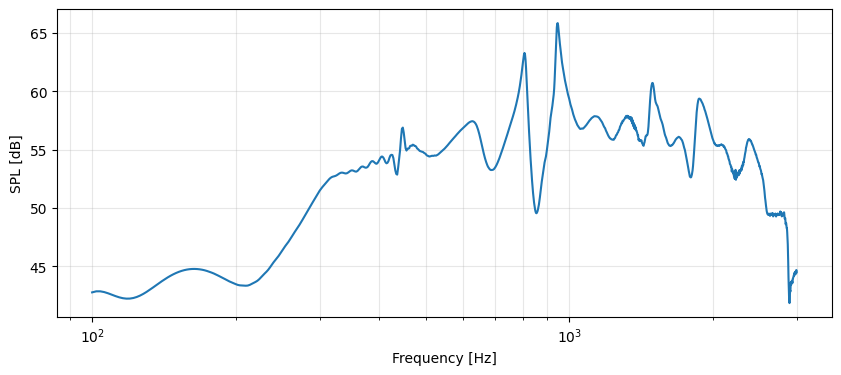

In [21]:
from matplotlib import pyplot as plt
f_axis_td = np.fft.fftfreq(len(P_25_FD_from_TD), dt)

mask = (f_axis_td >= 100) & (f_axis_td <= 3000)

plt.figure(figsize=(10,4))
plt.plot(f_axis_td[mask], P_25_FD_from_TD_DB[mask])
plt.xscale("log")
plt.xlabel("Frequency [Hz]")
plt.ylabel("SPL [dB]")
plt.grid(which="both", alpha=0.3)

plt.show()

In [24]:
from frequency_domain import monopole_multi_fa__calcf__outf
P_total, P_z, P_y = run_simulation_semi_circle_total(
        circle_centre=semi_circle_centre,
        circle_radius=2.5,
        number_of_points=5,
        simulation_function=monopole_multi_fa__calcf__outf,
        V_z=triangle_v_z_fd.T,
        A_z=projected_area_y[:, None],
        V_y=triangle_v_y_fd.T,
        A_y=projected_area_x[:, None],
        return_components=True,
        freqs=f_sim_axis[frequncy_mask],
        X=centre_sim,
    )


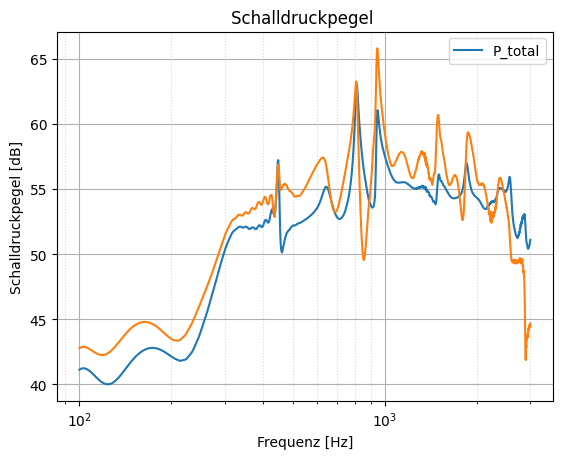

In [26]:
p0 = 2e-5

P_total_db = 20 * np.log10((np.abs(P_total) + p0) / p0)
P_z_db = 20 * np.log10((np.abs(P_z) + p0) / p0)
P_y_db = 20 * np.log10((np.abs(P_y) + p0) / p0)

f_plot = f_sim_axis[frequncy_mask]
plt_mask = (f_plot >= 100) & (f_plot <= f_max)

plt_f_axis = f_plot[plt_mask]
plt_P_total_db = P_total_db[plt_mask]
plt_P_z_db = P_z_db[plt_mask]
plt_P_y_db = P_y_db[plt_mask]

plt.plot(plt_f_axis, plt_P_total_db, label="P_total")
plt.plot(f_axis_td[mask], P_25_FD_from_TD_DB[mask])
#plt.plot(plt_f_axis, plt_P_z_db, label="P_z")
#plt.plot(plt_f_axis, plt_P_y_db, label="P_y")
#plt.plot(wagner_simulation_data[:, 0], wagner_simulation_data[:, 1], label="FEM Simulation")
plt.xlabel('Frequenz [Hz]')
plt.ylabel('Schalldruckpegel [dB]')
plt.legend()
plt.xscale('log')
plt.grid(True, which='major')
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.title('Schalldruckpegel ')
plt.show()